# Pixels to Predictions: CS-GY 6953 (Deep Learning) Kaggle Competition
## MODEL 1 (First attempt)
### Author: Mariia Onokhina
**Objective:** Build a model that can answer visual multiple-choice questions based on scientific diagrams and text.

**Baseline Model:** `HuggingFaceTB/SmolVLM-500M-Instruct` (~500 M params)
**Fine-Tuning:** QLoRA (4-bit NF4)
**Scoring:** Multiple-choice log-likelihood

---

## Installation of Libraries 

Before installing any libraries, I create a new Conda environment and add it to Jupyter Notebook to ensure I start from a clean slate and that the code is reproducible.

**Run the following code in a terminal if you'd like to start fresh with a new environment:**
```bash
conda create -n pixels-to-predictions python=3.10
conda activate pixels-to-predictions
conda install -c conda-forge notebook
conda install -c conda-forge ipykernel
python -m ipykernel install --user --name pixels-to-predictions --display-name "Pixels-to-predictions DL"
```

IMPORTANT: Manually change the Kernel in Jupyter Notebook in VS Code or Jupyter Lab to "Pixels-to-predictions DL".

In [2]:
# Uncomment this cell to install the necessary Python packages.
import sys
print("Python:", sys.executable)
!{sys.executable} -m pip install -q transformers==4.57.6 peft==0.18.1 kaggle matplotlib scikit-learn pandas numpy ipywidgets jupyterlab_widgets bitsandbytes accelerate datasets pillow --quiet

Python: /home/devvingduo/miniforge3/envs/pixels-to-predictions/bin/python


---
## Imports & Configuration

In [3]:
# Imports & Configuration
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import ast
from transformers import AutoProcessor, AutoModelForVision2Seq

# For LoRa fine-tuning
from peft import LoraConfig, get_peft_model
from tqdm.auto import tqdm   # For progress bar

In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
# Paths 
DATA_DIR = Path("data")
IMAGE_ROOT = DATA_DIR / "images"

# Model
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# Basic Settings
IMG_SIZE = 224

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3090


---
### Load and Preprocess Data

Download data from https://www.kaggle.com/competitions/pixels-to-predictions/data via Kaggle CLI.

For this, you need a Legacy API key which you can create here: https://www.kaggle.com/settings.

When you create a new key, it will download a ```kaggle.json```. 

In your terminal, run:
```bash
mkdir -p ~/.kaggle
mv <your_downloads_folder> ~/.kaggle/kaggle.json
chmod 600 ~/.kaggle/kaggle.json
```

Verify that it worked by running: 
```bash
ls -la ~/.kaggle
```

I have to add it manually because I'm working via SSH into my Linux server machine.

In [7]:
# Uncomment this cell to download the data in a .zip file
#!kaggle competitions download -c pixels-to-predictions

In [8]:
# Uncomment this cell to unzip the data into "data" folder
#!unzip pixels-to-predictions.zip -d data

In [9]:
# Load CSVs
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

Inspect the data. 

In [10]:
train_df.head(2)

,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,"[""the male's tadpoles will be larger when they...",3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[""the female's offspring will live longer"", ""t...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3109 entries, 0 to 3108
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           3109 non-null   object
 1   image_path   3109 non-null   object
 2   question     3109 non-null   object
 3   choices      3109 non-null   object
 4   num_choices  3109 non-null   int64 
 5   answer       3109 non-null   int64 
 6   hint         2385 non-null   object
 7   lecture      2669 non-null   object
 8   solution     2580 non-null   object
 9   task         3109 non-null   object
 10  grade        3109 non-null   object
 11  subject      3109 non-null   object
 12  topic        3109 non-null   object
 13  category     3109 non-null   object
 14  skill        3109 non-null   object
dtypes: int64(2), object(13)
memory usage: 364.5+ KB


In [12]:
val_df.head(2)

,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,val_00671,images/val/val_00671.png,Why might covering its eggs with its body incr...,"[""the leech's eggs will hatch"", ""the leech wil...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,val_04111,images/val/val_04111.png,Why might fanning eggs increase the reproducti...,"[""the male will build a nest for females to la...",3,1,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


In [13]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048 entries, 0 to 1047
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           1048 non-null   object
 1   image_path   1048 non-null   object
 2   question     1048 non-null   object
 3   choices      1048 non-null   object
 4   num_choices  1048 non-null   int64 
 5   answer       1048 non-null   int64 
 6   hint         816 non-null    object
 7   lecture      915 non-null    object
 8   solution     876 non-null    object
 9   task         1048 non-null   object
 10  grade        1048 non-null   object
 11  subject      1048 non-null   object
 12  topic        1048 non-null   object
 13  category     1048 non-null   object
 14  skill        1048 non-null   object
dtypes: int64(2), object(13)
memory usage: 122.9+ KB


In [14]:
test_df.head(2)

,id,image_path,question,choices,num_choices,hint,lecture,task,grade,subject,topic,category,skill
0,test_01750,images/test/test_01750.png,"Based on clues in the text, why would farmers ...","[""The cats were thought to be visiting goddess...",4,Read the text about cats.\nCats are among the ...,"Informational texts include many facts, exampl...",closed choice,grade5,language science,reading-comprehension,Informational texts: level 1,Read passages about animals
1,test_00128,images/test/test_00128.png,What is the probability that an American curl ...,"[""0/4"", ""2/4"", ""4/4"", ""3/4"", ""1/4""]",5,"In a group of American curl cats, some individ...",Offspring genotypes: homozygous or heterozygou...,closed choice,grade8,natural science,biology,Genes to traits,Use Punnett squares to calculate probabilities...


In [15]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           1008 non-null   object
 1   image_path   1008 non-null   object
 2   question     1008 non-null   object
 3   choices      1008 non-null   object
 4   num_choices  1008 non-null   int64 
 5   hint         794 non-null    object
 6   lecture      825 non-null    object
 7   task         1008 non-null   object
 8   grade        1008 non-null   object
 9   subject      1008 non-null   object
 10  topic        1008 non-null   object
 11  category     1008 non-null   object
 12  skill        1008 non-null   object
dtypes: int64(1), object(12)
memory usage: 102.5+ KB


It seems like most of the columns are non-null, besides ```lecture``` and ```hint```.

In [16]:
# Function to parse the choices column using ast module (Abstract Syntax Tree)
def parse_choices(x):
    # If x is already a list, return it
    if isinstance(x, list):
        return x
    # If x is a string, parse it using ast.literal_eval
    return ast.literal_eval(x)

The ```choices``` column is a JSON string, so we parse it using the function above.

In [17]:
for df in [train_df, val_df, test_df]:
    df["choices_list"] = df["choices"].apply(parse_choices)

In [18]:
train_df[["id", "question", "choices_list", "answer"]].head(2)

,id,question,choices_list,answer
0,train_07667,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,2
1,train_02628,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",0


In [19]:
train_df["choices_list"].iloc[0]

["the male's tadpoles will be larger when they hatch",
 'the male will carry his tadpoles through the forest',
 "the male's tadpoles will become adult frogs"]

Check lengths of the dataframes.

In [20]:
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Train: 3,109 | Val: 1,048 | Test: 1,008


Check answer validity. If correct answer index is less than 0 or bigger than the number of choices, it's invalid and we should not train on them.

In [21]:
def check_answers(df, name):
    bad = df[(df["answer"] < 0) | (df["answer"] >= df["num_choices"])]
    print(name, "bad answers:", len(bad))

check_answers(train_df, "train")
check_answers(val_df, "val")

train bad answers: 0
val bad answers: 0


There are no invalid answers.

Check class distribution, whether some answers repeat more often that others. 

In [22]:
print(train_df["answer"].value_counts(normalize=True).sort_index())
print(val_df["answer"].value_counts(normalize=True).sort_index())

answer
0    0.361531
1    0.330653
2    0.237054
3    0.065616
4    0.005146
Name: proportion, dtype: float64
answer
0    0.331107
1    0.354962
2    0.235687
3    0.071565
4    0.006679
Name: proportion, dtype: float64


There is a class imbalance. There is a strong skew toward: 0 and 1 (~70%). Guessing 0 and 1 would be correct most of the time, while guessing 3 or 4 is rare.

---
### Prompt Engineering

The prompt from the starter notebook is very generic. I will expand on the prompt, specifying all the parts of the question directly.

In [23]:
# This function builds the text prompt for the Vision Language Model.
def build_prompt(row: pd.Series, include_answer: bool = False) -> str:
    choices = row["choices_list"]

    choice_lines = "\n".join(
        [f"{i}. {c}" for i, c in enumerate(choices)]
    )

    # Build context only if it exists (hint and lecture)
    context_parts = []

    lecture = row.get("lecture", "")
    hint = row.get("hint", "")

    # If lecture exists and is not empty, add it to the context
    if pd.notna(lecture) and str(lecture).strip():
        context_parts.append(str(lecture).strip())

    # If hint exists and is not empty, add it to the context
    if pd.notna(hint) and str(hint).strip():
        context_parts.append(str(hint).strip())

    context_str = "\n".join(context_parts)

    # Build prompt
    prompt = "<image>\n"
    prompt += "You are solving a multiple-choice science question.\n"
    prompt += (
        "Analyze the image and read the question carefully.\n"
        "Use the context and hint if helpful.\n"
        "Eliminate incorrect choices and select the best answer.\n\n"
        )

    # Metadata 
    prompt += f"Grade: {row.get('grade','')}\n"
    prompt += f"Subject: {row.get('subject','')}\n"
    prompt += f"Topic: {row.get('topic','')}\n"
    prompt += f"Category: {row.get('category','')}\n"
    prompt += f"Skill: {row.get('skill','')}\n\n"
    
    # Add context only if exists
    if context_str:
        prompt += f"Context:\n{context_str}\n\n"

    prompt += f"Question:\n{row['question']}\n\n"
    prompt += f"Choices:\n{choice_lines}\n\n"

    # Make sure the answer is returned as a single integer and not a whole bunch of explanation
    prompt += (
        f"Return ONLY a single integer (0-{len(choices)-1}). "
        "Do not explain.\n"
        )
    
    prompt += "Answer:"

    # For training purposes, we can include the answer in the prompt
    if include_answer:
        answer_idx = int(row["answer"])
        prompt += f" {answer_idx}"

    return prompt

# Display an example prompt
print(build_prompt(train_df.iloc[0], include_answer=True))


<image>
You are solving a multiple-choice science question.
Analyze the image and read the question carefully.
Use the context and hint if helpful.
Eliminate incorrect choices and select the best answer.

Grade: grade8
Subject: natural science
Topic: literacy-in-science
Category: Adaptations and natural selection
Skill: How can animal behaviors affect reproductive success? Identify evidence to support a claim

Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their

---
### PyTorch Dataset

In [24]:
class ScienceQADataset(Dataset):
    def __init__(self, df: pd.DataFrame, data_dir: Path, image_root: Path, is_train: bool = True):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.image_root = image_root
        self.is_train = is_train

    def __len__(self) -> int:
        return len(self.df)

    def _load_image(self, rel_path: str) -> Image.Image:
        return Image.open(self.image_root / rel_path).convert("RGB")

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        img = self._load_image(row["image_path"])

        item = {
            "id": row["id"],
            "image": img,
            "text": build_prompt(row, include_answer=self.is_train),
            "prompt": build_prompt(row, include_answer=False),
            "choices": row["choices_list"],
            "num_choices": int(row["num_choices"]),

        }
        
        if "answer" in row and pd.notna(row["answer"]):
            item["answer"] = int(row["answer"])
        else:
            item["answer"] = -1
        
        return item

# Create datasets
train_ds = ScienceQADataset(train_df, DATA_DIR, IMAGE_ROOT, is_train=True)
val_ds = ScienceQADataset(val_df, DATA_DIR, IMAGE_ROOT, is_train=False)
test_ds = ScienceQADataset(test_df, DATA_DIR, IMAGE_ROOT, is_train=False)

print(f"Datasets created: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

Datasets created: train=3109, val=1048, test=1008


Inspect an example from each dataset.

In [25]:
sample_train = train_ds[0]
sample_val = val_ds[0]
sample_test = test_ds[0]

In [26]:
print(sample_train.keys())
print(sample_val.keys())
print(sample_test.keys())

dict_keys(['id', 'image', 'text', 'prompt', 'choices', 'num_choices', 'answer'])
dict_keys(['id', 'image', 'text', 'prompt', 'choices', 'num_choices', 'answer'])
dict_keys(['id', 'image', 'text', 'prompt', 'choices', 'num_choices', 'answer'])


In [27]:
# Check the type of the image and its size
print(type(sample_train["image"]))
print(sample_train["image"].size)

<class 'PIL.Image.Image'>
(302, 252)


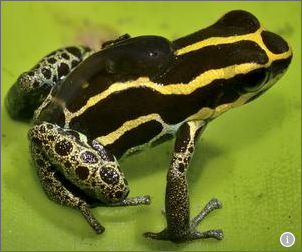

In [28]:
# Visualize an image
display(sample_train["image"])

---
### Model Loading and Inference Example

This section loads `HuggingFaceTB/SmolVLM-500M-Instruct` and runs a quick inference example on one validation sample.

In [29]:
# Load SmolVLM model + run one inference example
processor = AutoProcessor.from_pretrained(MODEL_ID)

if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

dtype = torch.float16 if torch.cuda.is_available() else torch.float32
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto",
    low_cpu_mem_usage=True,
    )

/home/devvingduo/miniforge3/envs/pixels-to-predictions/lib/python3.10/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


In [30]:
model.eval()

# Pick a sample from validation set
sample = val_df.iloc[0]
sample_image = Image.open(IMAGE_ROOT / sample["image_path"]).convert("RGB")
sample_prompt = build_prompt(sample, include_answer=False)

inputs = processor(
    text=[sample_prompt],
    images=[sample_image],
    return_tensors="pt",
)

inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
    )

decoded = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Prompt:")
print(sample_prompt)
print("\nModel output:")
print(decoded)
print(f"\nGround-truth answer index: {sample['answer']}")

Prompt:
<image>
You are solving a multiple-choice science question.
Analyze the image and read the question carefully.
Use the context and hint if helpful.
Eliminate incorrect choices and select the best answer.

Grade: grade8
Subject: natural science
Topic: literacy-in-science
Category: Adaptations and natural selection
Skill: How can animal behaviors affect reproductive success? Identify evidence to support a claim

Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may fe

The model keeps generating, despite us telling it to only output an integer as the answer. It simply continues the input text with whatever tokens it predicts next. Even though the prompt says “Return only a single integer,” that instruction is not a hard constraint, so the model may still continue with extra text, repeat the prompt, or output a choice explanation.

Instead of generating free-form text, we score each possible answer choice using the same SmolVLM model and choose the option with the highest likelihood.

In [31]:
def score_choice(model, processor, image, prompt, choice_text):
    """
    Score only the candidate answer tokens.
    Higher score means the model thinks this answer is more likely.
    """
    answer_text = " " + str(choice_text)
    full_text = prompt + answer_text

    # Tokenize full prompt + candidate answer
    inputs = processor(
        text=[full_text],
        images=[image],
        return_tensors="pt",
    )

    # Move tensors to model device
    inputs = {
        k: v.to(model.device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    input_ids = inputs["input_ids"]

    # Tokenize prompt only, so we know where answer tokens begin
    prompt_ids = processor.tokenizer(
        prompt,
        add_special_tokens=False
    )["input_ids"]

    prompt_len = len(prompt_ids)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.float()

    # Next-token log probabilities
    log_probs = F.log_softmax(logits[:, :-1, :], dim=-1)
    target_ids = input_ids[:, 1:]

    token_log_probs = log_probs.gather(
        2,
        target_ids.unsqueeze(-1)
    ).squeeze(-1)

    # Score only answer tokens
    start = max(prompt_len - 1, 0)
    answer_log_probs = token_log_probs[:, start:]

    # If no answer tokens, return -infinity (very bad score)
    if answer_log_probs.numel() == 0:
        return -1e9

    return answer_log_probs.mean().item()

In [32]:
# This function predicts the answer index for one sample by scoring all choices 
# and selecting the one with highest log-likelihood.
def predict_mc(model, processor, row):
    image = Image.open(IMAGE_ROOT / row["image_path"]).convert("RGB")
    prompt = build_prompt(row, include_answer=False)

    scores = []

    # Evaluate each candidate answer index
    for i, choice in enumerate(row["choices_list"]):
        # We score the index, not the full text
        score = score_choice(model, processor, image, prompt, str(i))
        scores.append(score)

    # Return index with highest score
    return int(torch.tensor(scores).argmax().item())

Test on a sample.

In [33]:
sample_pred = predict_mc(model, processor, sample)

print("Pred:", sample_pred)
print("GT:", sample["answer"])

Pred: 1
GT: 0


In [34]:
def predict_mc_debug(model, processor, row):
    image = Image.open(IMAGE_ROOT / row["image_path"]).convert("RGB")
    prompt = build_prompt(row, include_answer=False)

    scores = []
    for i, choice in enumerate(row["choices_list"]):
        score = score_choice(model, processor, image, prompt, str(i))
        scores.append(score)
        print(f"{i}: score={score:.4f} | choice={choice}")

    pred = int(torch.tensor(scores).argmax().item())
    print("Pred:", pred)
    print("GT:", int(row["answer"]))
    return pred

predict_mc_debug(model, processor, sample)

0: score=-8.6957 | choice=the leech's eggs will hatch
1: score=-8.6914 | choice=the leech will not eat for up to a week
2: score=-8.6960 | choice=the leech will fight a water snail
Pred: 1
GT: 0


1

In [35]:
correct = 0

for i in range(50):
    row = val_df.iloc[i]
    pred = predict_mc(model, processor, row)
    correct += int(pred == int(row["answer"]))

print("Accuracy on 50 samples:", correct / 50)

Accuracy on 50 samples: 0.4


---
### LoRa Adapters

Attach LoRA adapters.

In [36]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,080,768 || all params: 509,563,072 || trainable%: 0.4083


Trainable parameters are under 5,000,000 which is in compliance with competition rules.

---
### Model Training

Create a dataset just for training. It has prompt and answer, with masking.

In [37]:
class TrainDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(IMAGE_ROOT / row["image_path"]).convert("RGB")

        prompt = build_prompt(row, include_answer=False)
        answer = " " + str(int(row["answer"]))

        return {
            "image": image,
            "prompt": prompt,
            "answer": answer,
        }

Collate so that the model trains only on answer.

In [44]:
def train_collate_fn(batch):
    images = [b["image"] for b in batch]
    prompts = [b["prompt"] for b in batch]
    answers = [b["answer"] for b in batch]

    full_texts = [
        p + a for p, a in zip(prompts, answers)
    ]

    inputs = processor(
        text=full_texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    labels = inputs["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    for i, prompt in enumerate(prompts):
        prompt_ids = processor.tokenizer(
            prompt,
            add_special_tokens=False
        )["input_ids"]

        labels[i, :len(prompt_ids)] = -100

    inputs["labels"] = labels
    return inputs

Start on a small sample.

In [46]:
small_train_df = train_df.sample(200, random_state=42).reset_index(drop=True)

train_ds = TrainDataset(small_train_df)

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    collate_fn=train_collate_fn,
)

Train for 1 epoch.

In [47]:
model.train()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
)

for epoch in range(1):
    total_loss = 0

    for batch in tqdm(train_loader):
        batch = {
            k: v.to(model.device) if torch.is_tensor(v) else v
            for k, v in batch.items()
        }

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Avg loss:", total_loss / len(train_loader))

  0%|          | 0/200 [00:00<?, ?it/s]

Avg loss: 1.9013664777576924


Evaluate on a small sample again.

In [48]:
model.eval()

N = 200
correct = 0

for i in range(N):
    row = val_df.iloc[i]
    pred = predict_mc(model, processor, row)
    correct += int(pred == int(row["answer"]))

print("LoRA accuracy:", correct / N)

LoRA accuracy: 0.435


The accuracy is pretty low, probably because I trained on a small subset of data. I will train for the whole training dataset. Also, use smaller learning rate.

In [49]:
# Delete previous model to start from scratch
del model
torch.cuda.empty_cache()

In [50]:
train_ds = TrainDataset(train_df)

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    collate_fn=train_collate_fn,
)

Reload clean base model.

In [51]:
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto",
    low_cpu_mem_usage=True,
    )
model.eval()

/home/devvingduo/miniforge3/envs/pixels-to-predictions/lib/python3.10/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_features=768, out

Reattach LoRA.

In [52]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,080,768 || all params: 509,563,072 || trainable%: 0.4083


Recreate optimizer after LoRA is attached.

In [53]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.01,
)

Train for 1 epoch for now.

In [54]:
model.train()

accum_steps = 4
total_loss = 0

optimizer.zero_grad()

for step, batch in enumerate(tqdm(train_loader)):
    batch = {
        k: v.to(model.device) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }

    outputs = model(**batch)
    loss = outputs.loss / accum_steps

    loss.backward()

    if (step + 1) % accum_steps == 0:
        optimizer.step()
        optimizer.zero_grad()

    total_loss += loss.item() * accum_steps

print("Avg loss:", total_loss / len(train_loader))

  0%|          | 0/3109 [00:00<?, ?it/s]

Avg loss: 1.5073625889764641


In [55]:
model.eval()

N = 200
correct = 0

for i in range(N):
    row = val_df.iloc[i]
    pred = predict_mc(model, processor, row)
    correct += int(pred == int(row["answer"]))

print("LoRA accuracy:", correct / N)

LoRA accuracy: 0.455


---
### Submission

The evaluation loss is pretty low on a small sample (0.455). I still will generate a submission.csv to submit something.

In [56]:
SAVE_DIR = "lora_checkpoint"

model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

['lora_checkpoint/processor_config.json']

In [57]:
test_preds = []

for i in tqdm(range(len(test_df))):
    row = test_df.iloc[i]
    pred = predict_mc(model, processor, row)
    test_preds.append(pred)

  0%|          | 0/1008 [00:00<?, ?it/s]

In [58]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "answer": test_preds,
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,answer
0,test_01750,1
1,test_00128,1
2,test_02891,1
3,test_02425,1
4,test_00930,2


This submission.csv achieved 0.519 score on public dataset.